In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
print("Libraries imported successfully")

Libraries imported successfully


In [15]:
df = pd.read_csv("data/Churn_Modelling.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
print("Data information:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget distribution:")
print(df["Exited"].value_counts())

Data information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore

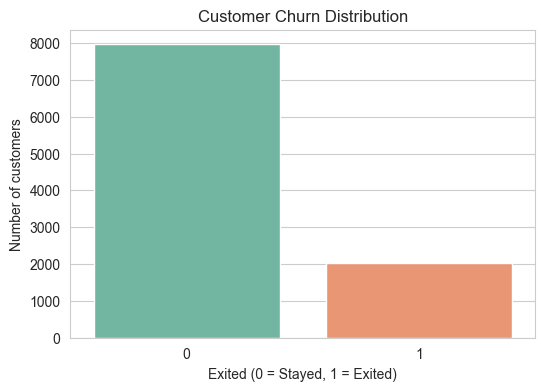

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Exited", hue="Exited", legend=False, palette="Set2")
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Exited)")
plt.ylabel("Number of customers")
plt.show()

In [18]:
data = df.drop(columns=["RowNumber", "CustomerId", "Surname"]).copy()
X = data.drop(columns=["Exited"])
y = data["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("X:", X.shape, "y:", y.shape)
print("Training:", X_train.shape, "Testing:", X_test.shape)

X: (10000, 10) y: (10000,)
Training: (8000, 10) Testing: (2000, 10)


In [19]:
numeric_features = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"]
categorical_features = ["Geography", "Gender"]

preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])
print("Preprocessor is ready")

Preprocessor is ready


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5, class_weight="balanced", random_state=42, n_jobs=-1)
}

pipelines = {}
predictions = {}
for name, estimator in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)   
    pipelines[name] = pipe 
    predictions[name] = pipe.predict(X_test)
    print(name, "trained") 

Logistic Regression trained
Decision Tree trained
Random Forest trained


In [21]:
rows = []
for name, pipe in pipelines.items():
    pred = predictions[name]
    prob = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })
results = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(results.style.format({c:"{:.4f}" for c in results.columns[1:]}))
best_name = results.loc[0, "Model"]
best_model = pipelines[best_name]
print("Selected model:", best_name)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.8170,0.5380,0.7125,0.6131,0.8612
1,Decision Tree,0.7615,0.4497,0.7690,0.5675,0.8398
2,Logistic Regression,0.7135,0.3872,0.7002,0.4987,0.7772


Selected model: Random Forest


<Figure size 800x400 with 0 Axes>

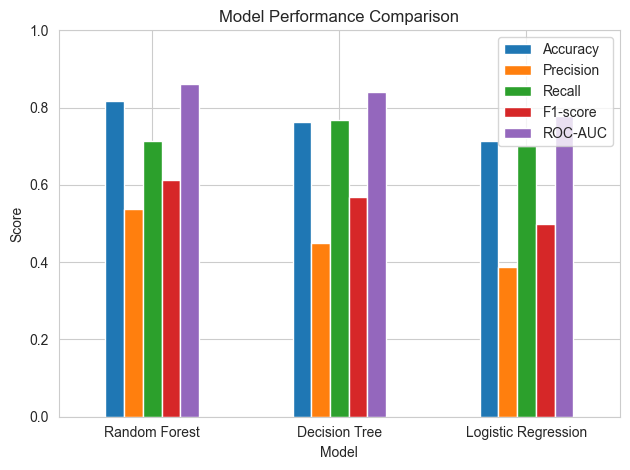

In [22]:
plt.figure(figsize=(8,4))
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(kind="bar", ylim=(0,1), rot=0)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [28]:
churn_by_geography = df.groupby("Geography")["Exited"].mean().mul(100).round(2).sort_values(ascending=False)
churn_by_activity = df.groupby("IsActiveMember")["Exited"].mean().mul(100).round(2)
product_analysis = df.groupby("NumOfProducts")["Exited"].agg(["count", "sum", "mean"])
product_analysis["churn_rate"] = (product_analysis["mean"] * 100).round(2)
print("Churn by geography (%):\n", churn_by_geography)
print("\nChurn by activity (%):\n", churn_by_activity.rename(index={0:"Inactive",1:"Active"}))
print("\nProduct analysis:")
display(product_analysis)

Churn by geography (%):
 Geography
Germany    32.44
Spain      16.67
France     16.15
Name: Exited, dtype: float64

Churn by activity (%):
 IsActiveMember
Inactive    26.85
Active      14.27
Name: Exited, dtype: float64

Product analysis:


,count,sum,mean,churn_rate
NumOfProducts,,,,
1,5084,1409,0.277144,27.71
2,4590,348,0.075817,7.58
3,266,220,0.827068,82.71
4,60,60,1.000000,100.00


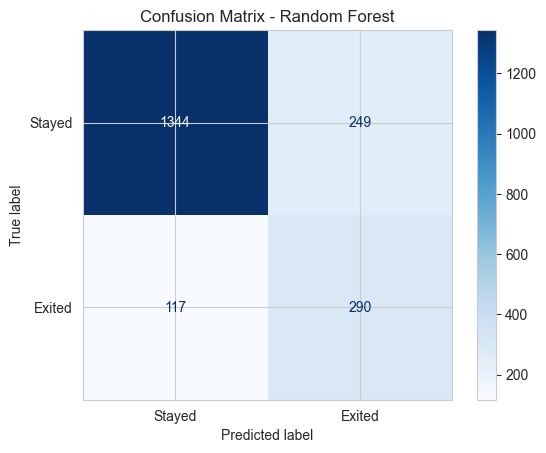

              precision    recall  f1-score   support

      Stayed       0.92      0.84      0.88      1593
      Exited       0.54      0.71      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



In [24]:
best_predictions = predictions[best_name]
ConfusionMatrixDisplay.from_predictions(y_test, best_predictions, display_labels=["Stayed", "Exited"], cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()
print(classification_report(y_test, best_predictions, target_names=["Stayed", "Exited"], zero_division=0))

In [29]:
def classify_risk(probability):
    if probability < 0.30:
        return "Low Risk", "Routine follow-up"
    if probability < 0.60:
        return "Medium Risk", "Contact the customer and offer support"
    return "High Risk", "Provide a personalized retention offer"

customer_example = pd.DataFrame([{
    "CreditScore": 650, "Geography": "Germany", "Gender": "Female", "Age": 50,
    "Tenure": 2, "Balance": 150000, "NumOfProducts": 3, "HasCrCard": 1,
    "IsActiveMember": 0, "EstimatedSalary": 100000
}])
probability = best_model.predict_proba(customer_example)[0,1]
prediction = int(best_model.predict(customer_example)[0])
risk, recommendation = classify_risk(probability)
print("Prediction:", "May Exit" if prediction == 1 else "Likely to Stay")
print(f"Churn Probability: {probability:.1%}")
print("Risk Level:", risk)
print("Recommendation:", recommendation)

Prediction: May Exit
Churn Probability: 92.5%
Risk Level: High Risk
Recommendation: Provide a personalized retention offer


In [26]:
joblib.dump(best_model, "best_model.joblib")
loaded_model = joblib.load("best_model.joblib")
print("Saved:", best_name)
print("Loaded type:", type(loaded_model))

Saved: Random Forest
Loaded type: <class 'sklearn.pipeline.Pipeline'>
